# PS4: Phân tích cơ cấu doanh thu và thị phần theo khu vực địa lý

**Mục tiêu:** Xác định mức đóng góp doanh thu của từng khu vực và đề xuất hướng phát triển.

1. Tính tỷ trọng doanh thu theo Region, City, District.
2. Xếp hạng các khu vực theo doanh thu.
3. Tìm khu vực doanh thu cao nhưng tăng trưởng thấp và doanh thu thấp nhưng tăng trưởng nhanh.
4. Đề xuất đầu tư, mở rộng hoặc tái phân bổ nguồn lực.

## Chuẩn bị: Đọc dữ liệu



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

orders = pd.read_csv("../../SilverData/orders_silver.csv")
geography = pd.read_csv("../../SilverData/geography_silver.csv")
payments = pd.read_csv("../../SilverData/payments_silver.csv")
returns = pd.read_csv("../../SilverData/returns_silver.csv")

orders["order_date"] = pd.to_datetime(orders["order_date"])

pd.options.display.float_format = "{:,.2f}".format

print("Orders:", orders.shape)
print("Geography:", geography.shape)
print("Payments:", payments.shape)
print("Returns:", returns.shape)


Orders: (646945, 9)
Geography: (39948, 4)
Payments: (646945, 4)
Returns: (39939, 7)


## Chuẩn bị: Gộp hoàn trả và ghép bảng

Một đơn có thể có nhiều dòng hoàn trả. Cộng tiền hoàn theo `order_id` trước để ghép không bị nhân đôi doanh thu.

In [2]:
refund_by_order = (
    returns.groupby("order_id", as_index=False)
    .agg(total_refund=("refund_amount", "sum"))
)

df = orders.merge(
    geography, on="zip", how="left", validate="many_to_one"
)
df = df.merge(
    payments, on="order_id", how="left", validate="one_to_one"
)
df = df.merge(
    refund_by_order, on="order_id", how="left", validate="one_to_one"
)

print("Số đơn trước ghép:", len(orders))
print("Số dòng sau ghép:", len(df))
print("Số giá trị thiếu ở các cột cần phân tích:")
display(df[["region", "city", "district", "payment_value", "order_date"]].isna().sum())


Số đơn trước ghép: 646945
Số dòng sau ghép: 646945
Số giá trị thiếu ở các cột cần phân tích:


region           0
city             0
district         0
payment_value    0
order_date       0
dtype: int64

## Chuẩn bị: Tính doanh thu thuần

Đơn đã giao không có bản ghi trả hàng được tính tiền hoàn bằng 0. Đơn có trạng thái `returned` nhưng thiếu thông tin hoàn tiền được loại trước khi điền 0.

In [3]:
df_revenue = df.loc[
    df["order_status"].isin(["delivered", "returned"])
].copy()

missing_refund = (
    (df_revenue["order_status"] == "returned")
    & df_revenue["total_refund"].isna()
)

print("Đơn returned thiếu dữ liệu hoàn tiền:", missing_refund.sum())
df_revenue_valid = df_revenue.loc[~missing_refund].copy()

df_revenue_valid["total_refund"] = df_revenue_valid["total_refund"].fillna(0)
df_revenue_valid["net_revenue"] = (
    df_revenue_valid["payment_value"] - df_revenue_valid["total_refund"]
)

total_revenue = df_revenue_valid["net_revenue"].sum()

print("Số đơn dùng phân tích:", len(df_revenue_valid))
print("Tổng doanh thu thuần: {:,.2f}".format(total_revenue))


Đơn returned thiếu dữ liệu hoàn tiền: 80
Số đơn dùng phân tích: 552778
Tổng doanh thu thuần: 12,871,731,922.00


## Phần 1: Tính tỷ trọng doanh thu

Tỷ trọng (%) = doanh thu thuần của khu vực / tổng doanh thu thuần toàn hệ thống × 100.

Region, City và District đều được chia cho cùng tổng doanh thu toàn hệ thống. Vì vậy, tỷ trọng của tất cả Region cộng lại bằng 100%; City và District cũng tương tự khi tính đủ các địa bàn.

Trong bài này, “thị phần” được hiểu là phần đóng góp doanh thu của từng địa bàn trong công ty. Dữ liệu chưa có doanh thu của đối thủ nên chưa tính được thị phần của công ty trên toàn thị trường.

### Tỷ trọng theo Region

In [4]:
revenue_region = (
    df_revenue_valid.groupby(['region'], as_index=False)
    .agg(net_revenue=("net_revenue", "sum"))
)

revenue_region["share_pct"] = (
    revenue_region["net_revenue"] / total_revenue * 100
)

display(revenue_region)


,region,net_revenue,share_pct
0,Central,"3,870,298,201.44",30.07
1,East,"5,987,509,721.22",46.52
2,West,"3,013,923,999.34",23.42


<Axes: title={'center': 'Tỷ trọng doanh thu thuần theo Region'}>

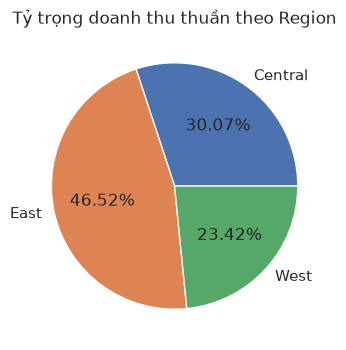

In [5]:
revenue_region.plot(
    kind="pie",
    y="share_pct",
    labels=revenue_region["region"],
    autopct="%1.2f%%",
    legend=False,
    title="Tỷ trọng doanh thu thuần theo Region",
    figsize=(4, 4),
    ylabel=""
)


### Tỷ trọng theo City

In [6]:
revenue_city = (
    df_revenue_valid.groupby(['region', 'city'], as_index=False)
    .agg(net_revenue=("net_revenue", "sum"))
)

revenue_city["share_pct"] = (
    revenue_city["net_revenue"] / total_revenue * 100
)

display(revenue_city)


,region,city,net_revenue,share_pct
0,Central,Da Nang,"299,973,532.27",2.33
1,Central,Dong Hoi,"324,893,475.10",2.52
2,Central,Hoi An,"316,832,841.58",2.46
3,Central,Hue,"352,908,728.31",2.74
4,Central,Kon Tum,"362,720,330.18",2.82
5,Central,Nha Trang,"307,753,216.14",2.39
6,Central,Phan Rang-Thap Cham,"321,356,729.55",2.50
7,Central,Phan Thiet,"337,736,502.19",2.62
8,Central,Quang Ngai,"341,221,270.90",2.65
9,Central,Quy Nhon,"323,155,113.43",2.51


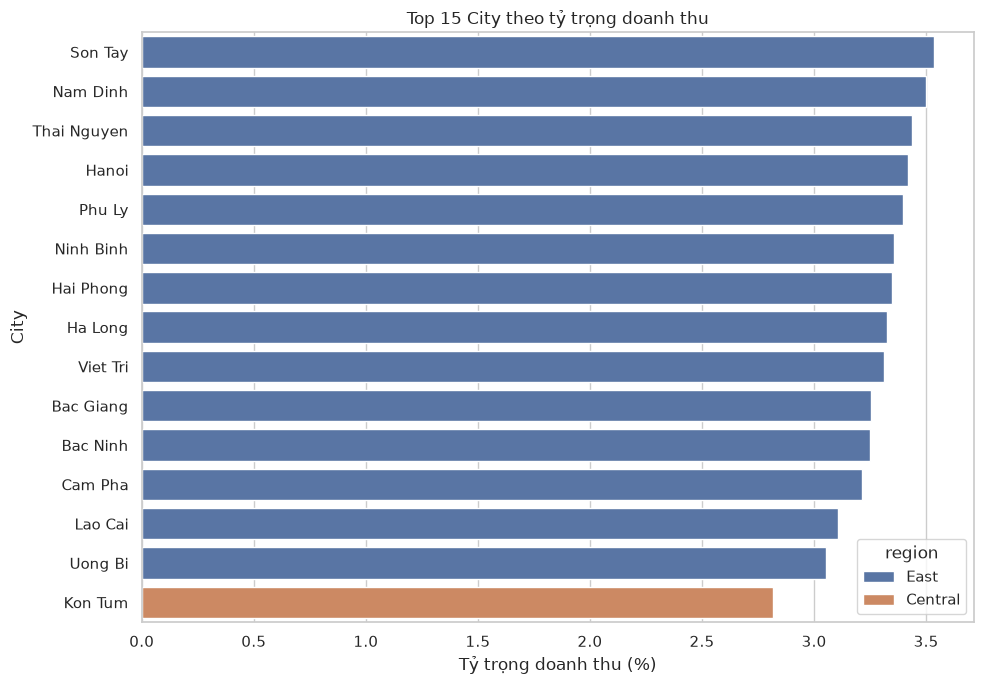

In [7]:
top_city = revenue_city.nlargest(15, "share_pct")

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_city,
    x="share_pct",
    y="city",
    hue="region",
    dodge=False
)

plt.title("Top 15 City theo tỷ trọng doanh thu")
plt.xlabel("Tỷ trọng doanh thu (%)")
plt.ylabel("City")
plt.tight_layout()
plt.show()


### Tỷ trọng theo District

In [8]:
revenue_district = (
    df_revenue_valid.groupby(['region', 'city', 'district'], as_index=False)
    .agg(net_revenue=("net_revenue", "sum"))
)

revenue_district["share_pct"] = (
    revenue_district["net_revenue"] / total_revenue * 100
)

display(revenue_district)
print("Tổng tỷ trọng District: {:.2f}%".format(revenue_district["share_pct"].sum()))


,region,city,district,net_revenue,share_pct
0,Central,Da Nang,District #20,"22,714,282.42",0.18
1,Central,Da Nang,District #21,"32,299,970.20",0.25
2,Central,Da Nang,District #22,"25,435,554.85",0.20
3,Central,Da Nang,District #23,"35,153,411.43",0.27
4,Central,Da Nang,District #24,"20,780,526.27",0.16
...,...,...,...,...,...
529,West,Vung Tau,District #35,"12,799,542.66",0.10
530,West,Vung Tau,District #36,"19,840,935.58",0.15
531,West,Vung Tau,District #37,"56,493,981.66",0.44
532,West,Vung Tau,District #38,"36,548,408.60",0.28


Tổng tỷ trọng District: 100.00%


## Phần 2: Xếp hạng các khu vực

Doanh thu cao nhất nhận hạng 1. `dense` cho các giá trị bằng nhau cùng hạng, không bỏ số hạng tiếp theo. City và District chỉ hiển thị top 20; bảng gốc vẫn giữ tất cả địa bàn.

### Xếp hạng Region

In [9]:
revenue_region["rank"] = (
    revenue_region["net_revenue"].rank(method="dense", ascending=False)
)
revenue_region = revenue_region.sort_values("net_revenue", ascending=False)

display(revenue_region.head(20))


,region,net_revenue,share_pct,rank
1,East,"5,987,509,721.22",46.52,1.00
0,Central,"3,870,298,201.44",30.07,2.00
2,West,"3,013,923,999.34",23.42,3.00


### Xếp hạng City

In [10]:
revenue_city["rank"] = (
    revenue_city["net_revenue"].rank(method="dense", ascending=False)
)
revenue_city = revenue_city.sort_values("net_revenue", ascending=False)

display(revenue_city.head(20))


,region,city,net_revenue,share_pct,rank
22,East,Son Tay,"455,235,657.45",3.54,1.00
19,East,Nam Dinh,"450,672,358.41",3.50,2.00
23,East,Thai Nguyen,"442,558,603.80",3.44,3.00
17,East,Hanoi,"439,988,876.54",3.42,4.00
21,East,Phu Ly,"437,343,191.75",3.40,5.00
20,East,Ninh Binh,"431,918,744.08",3.36,6.00
16,East,Hai Phong,"430,824,433.52",3.35,7.00
15,East,Ha Long,"428,154,913.25",3.33,8.00
25,East,Viet Tri,"426,542,989.21",3.31,9.00
12,East,Bac Giang,"419,019,532.45",3.26,10.00


### Xếp hạng District

In [11]:
revenue_district["rank"] = (
    revenue_district["net_revenue"].rank(method="dense", ascending=False)
)
revenue_district = revenue_district.sort_values("net_revenue", ascending=False)

display(revenue_district.head(20))


,region,city,district,net_revenue,share_pct,rank
374,East,Thai Nguyen,District #10,"59,957,461.98",0.47,1.00
497,West,Pleiku,District #38,"58,489,778.18",0.45,2.00
531,West,Vung Tau,District #37,"56,493,981.66",0.44,3.00
54,Central,Kon Tum,District #22,"53,737,370.50",0.42,4.00
16,Central,Dong Hoi,District #23,"49,911,446.38",0.39,5.00
120,Central,Quy Nhon,District #23,"48,257,340.31",0.37,6.00
42,Central,Hue,District #23,"47,222,276.55",0.37,7.00
102,Central,Phan Thiet,District #31,"45,918,372.98",0.36,8.00
41,Central,Hue,District #22,"45,650,610.19",0.35,9.00
510,West,Soc Trang,District #37,"45,493,762.33",0.35,10.00


### Biểu đồ tỷ trọng Region

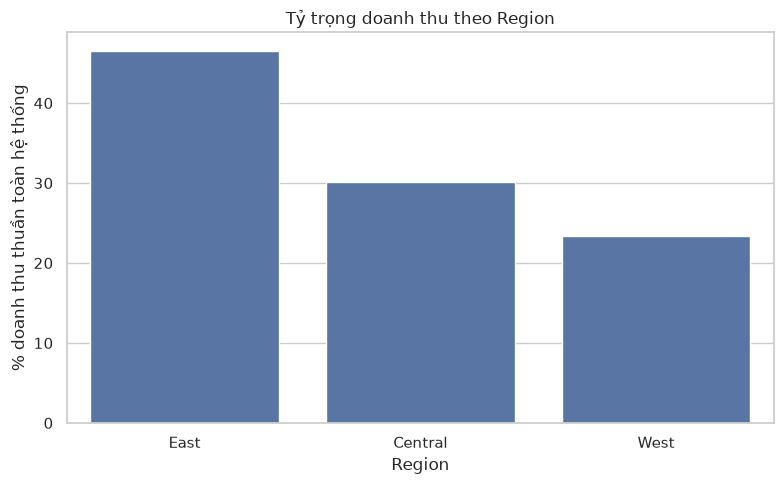

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=revenue_region, x="region", y="share_pct")
plt.title("Tỷ trọng doanh thu theo Region")
plt.xlabel("Region")
plt.ylabel("% doanh thu thuần toàn hệ thống")
plt.tight_layout()
plt.show()


## Phần 3: Xác định khu vực theo doanh thu và tốc độ tăng trưởng

**Phạm vi:** Nhóm chọn Region (vùng) để đánh giá tăng trưởng và đưa ra đề xuất ở Phần 3–4. City và District được dùng để xem chi tiết tỷ trọng và xếp hạng ở Phần 1–2. Đây là phạm vi phân tích nhóm lựa chọn.

Dữ liệu bắt đầu ngày 04/07/2012 nên năm 2012 không đủ 12 tháng. Nhóm dùng năm 2013 làm gốc và tính tăng trưởng từng năm từ **2014 đến 2022**: năm 2014 so với 2013, năm 2015 so với 2014, cứ tiếp tục như vậy.

- Tăng trưởng năm (%) = (Doanh thu năm nay − doanh thu năm trước) / doanh thu năm trước × 100.
- Doanh thu trung bình năm = tổng doanh thu từ 2014–2022 / 9 năm.
- Tăng trưởng trung bình năm = tổng 9 mức tăng trưởng từ 2014–2022 / 9.
- Doanh thu cao: doanh thu trung bình năm lớn hơn hoặc bằng trung vị của các Region. Trung vị là giá trị nằm giữa khi sắp xếp các giá trị tăng dần.
- Tăng trưởng nhanh: tăng trưởng trung bình lớn hơn 0 và lớn hơn hoặc bằng trung vị tăng trưởng của các Region.

Đây là cách phân nhóm do nhóm lựa chọn, không phải ngưỡng bắt buộc của đề. Tăng trưởng âm là doanh thu giảm; không gọi vùng giảm ít hơn là tăng trưởng nhanh.

**Lưu ý:** Trung bình các mức tăng trưởng năm không phải mức tăng trưởng cộng dồn của cả giai đoạn. Một vùng có thể tăng trong năm cuối nhưng tăng trưởng trung bình cả giai đoạn vẫn âm.

Tiền hoàn được tính vào năm đặt hàng gốc. Phần 1–2 dùng toàn bộ dữ liệu 2012–2022, còn phần đánh giá trung bình này dùng 2014–2022 để các năm có đủ 12 tháng.

In [13]:
df_revenue_valid["year"] = df_revenue_valid["order_date"].dt.year

df_year = df_revenue_valid.loc[
    df_revenue_valid["year"].between(2013, 2022)
].copy()

print("Năm dùng làm gốc:", 2013)
print("Các năm tính tăng trưởng: 2014 đến 2022")
print("Số đơn dùng phân tích theo năm:", len(df_year))


Năm dùng làm gốc: 2013
Các năm tính tăng trưởng: 2014 đến 2022
Số đơn dùng phân tích theo năm: 525296


### Tăng trưởng doanh thu qua từng năm — Region


In [14]:
annual_region = (
    df_year.groupby(["region", "year"], as_index=False)
    .agg(net_revenue=("net_revenue", "sum"))
    .sort_values(["region", "year"])
)

annual_region["growth_pct"] = (
    annual_region.groupby("region")["net_revenue"].pct_change() * 100
)

annual_growth_region = annual_region.loc[
    annual_region["year"].between(2014, 2022)
].copy()

display(annual_growth_region)


,region,year,net_revenue,growth_pct
1,Central,2014,"415,964,726.67",9.62
2,Central,2015,"407,808,208.73",-1.96
3,Central,2016,"478,872,352.95",17.43
4,Central,2017,"435,521,982.78",-9.05
5,Central,2018,"470,387,765.68",8.01
6,Central,2019,"285,970,411.28",-39.21
7,Central,2020,"272,770,139.15",-4.62
8,Central,2021,"259,115,662.83",-5.01
9,Central,2022,"291,077,157.76",12.33
11,East,2014,"693,612,690.10",13.60


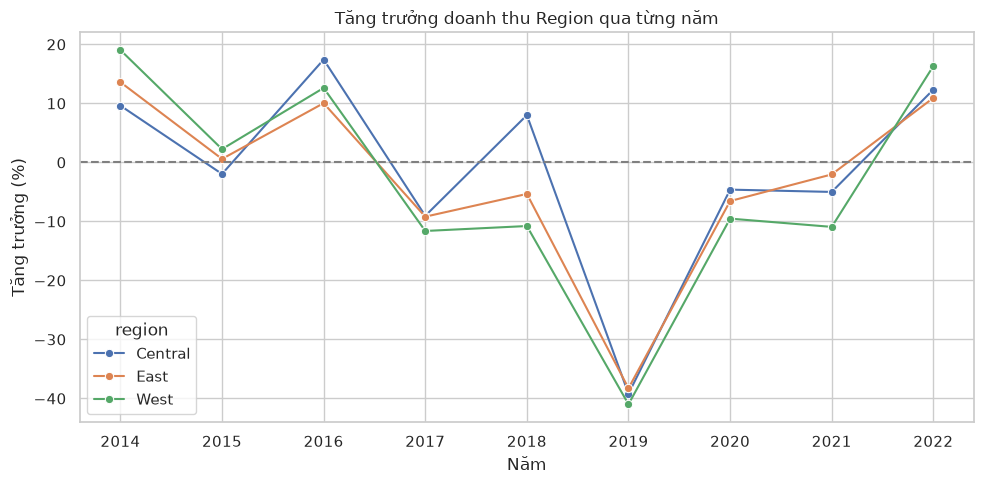

In [15]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=annual_growth_region,
    x="year",
    y="growth_pct",
    hue="region",
    marker="o"
)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Tăng trưởng doanh thu Region qua từng năm")
plt.xlabel("Năm")
plt.ylabel("Tăng trưởng (%)")
plt.tight_layout()
plt.show()


### Đánh giá Region theo hai tiêu chí


In [16]:
growth_region = (
    annual_growth_region.groupby("region", as_index=False)
    .agg(
        avg_annual_revenue=("net_revenue", "mean"),
        avg_growth_pct=("growth_pct", "mean")
    )
)

median_revenue_region = growth_region["avg_annual_revenue"].median()
median_growth_region = growth_region["avg_growth_pct"].median()

high_revenue_region = (
    growth_region["avg_annual_revenue"] >= median_revenue_region
)
fast_growth_region = (
    (growth_region["avg_growth_pct"] > 0)
    & (growth_region["avg_growth_pct"] >= median_growth_region)
)

growth_region["market_group"] = "Doanh thu thấp - tăng trưởng thấp"
growth_region.loc[
    high_revenue_region & ~fast_growth_region, "market_group"
] = "Doanh thu cao - tăng trưởng thấp"
growth_region.loc[
    ~high_revenue_region & fast_growth_region, "market_group"
] = "Doanh thu thấp - tăng trưởng nhanh"
growth_region.loc[
    high_revenue_region & fast_growth_region, "market_group"
] = "Doanh thu cao - tăng trưởng nhanh"

display(growth_region.sort_values("avg_annual_revenue", ascending=False))


,region,avg_annual_revenue,avg_growth_pct,market_group
1,East,"565,570,776.59",-2.92,Doanh thu cao - tăng trưởng thấp
0,Central,"368,609,823.09",-1.38,Doanh thu cao - tăng trưởng thấp
2,West,"284,386,393.03",-3.74,Doanh thu thấp - tăng trưởng thấp


### Hai nhóm cần xác định theo yêu cầu đề — Region


In [17]:
high_revenue_low_growth_region = growth_region.loc[
    growth_region["market_group"] == "Doanh thu cao - tăng trưởng thấp"
].sort_values("avg_annual_revenue", ascending=False)

low_revenue_fast_growth_region = growth_region.loc[
    growth_region["market_group"] == "Doanh thu thấp - tăng trưởng nhanh"
].sort_values("avg_growth_pct", ascending=False)

print("Region doanh thu cao - tăng trưởng thấp:")
display(high_revenue_low_growth_region)

print("Region doanh thu thấp - tăng trưởng nhanh:")
display(low_revenue_fast_growth_region)


Region doanh thu cao - tăng trưởng thấp:


,region,avg_annual_revenue,avg_growth_pct,market_group
1,East,"565,570,776.59",-2.92,Doanh thu cao - tăng trưởng thấp
0,Central,"368,609,823.09",-1.38,Doanh thu cao - tăng trưởng thấp


Region doanh thu thấp - tăng trưởng nhanh:


,region,avg_annual_revenue,avg_growth_pct,market_group


## Phần 4: Đề xuất chiến lược cho từng Region

Bảng dưới đưa ra hướng xử lý dựa trên nhóm doanh thu và tăng trưởng của từng Region:

- **Doanh thu cao, tăng trưởng nhanh:** xem xét đầu tư thêm sau khi kiểm tra nhu cầu và khả năng phục vụ.
- **Doanh thu cao, tăng trưởng thấp:** duy trì vùng đóng góp lớn, tìm nguyên nhân doanh thu chậm lại hoặc giảm.
- **Doanh thu thấp, tăng trưởng nhanh:** thử mở rộng từng bước và theo dõi kết quả; mức tăng cao có thể do doanh thu ban đầu nhỏ.
- **Doanh thu thấp, tăng trưởng thấp:** xem lại nhu cầu, chi phí và cách tiếp cận khách trước khi tăng hoặc giảm nguồn lực.

Đây là các hướng đề xuất để xem xét thêm. Doanh thu và tăng trưởng chưa đủ để quyết định đầu tư vì dữ liệu chưa có chi phí và lợi nhuận theo vùng.

### Đề xuất theo Region

In [18]:
strategy_region = growth_region.copy()

strategy_region["recommendation"] = "Kiểm tra dữ liệu và nền doanh thu trước khi đầu tư"
strategy_region.loc[
    strategy_region["market_group"] == "Doanh thu cao - tăng trưởng nhanh",
    "recommendation"
] = "Ưu tiên khảo sát đầu tư và mở rộng phục vụ"
strategy_region.loc[
    strategy_region["market_group"] == "Doanh thu cao - tăng trưởng thấp",
    "recommendation"
] = "Duy trì thị trường trọng điểm; tìm nguyên nhân chậm lại hoặc suy giảm"
strategy_region.loc[
    strategy_region["market_group"] == "Doanh thu thấp - tăng trưởng nhanh",
    "recommendation"
] = "Thử mở rộng từng bước; kiểm tra nền nhỏ và nhu cầu thực tế"
strategy_region.loc[
    strategy_region["market_group"] == "Doanh thu thấp - tăng trưởng thấp",
    "recommendation"
] = "Rà soát nhu cầu, chi phí; cân nhắc tái phân bổ nguồn lực"

strategy_region = strategy_region.sort_values("avg_annual_revenue", ascending=False)
display(strategy_region)


,region,avg_annual_revenue,avg_growth_pct,market_group,recommendation
1,East,"565,570,776.59",-2.92,Doanh thu cao - tăng trưởng thấp,Duy trì thị trường trọng điểm; tìm nguyên nhân...
0,Central,"368,609,823.09",-1.38,Doanh thu cao - tăng trưởng thấp,Duy trì thị trường trọng điểm; tìm nguyên nhân...
2,West,"284,386,393.03",-3.74,Doanh thu thấp - tăng trưởng thấp,"Rà soát nhu cầu, chi phí; cân nhắc tái phân bổ..."


## Kết luận từ kết quả phân tích

Tính trên toàn bộ dữ liệu, **East đóng góp khoảng 46,52%**, **Central 30,07%** và **West 23,42%** doanh thu thuần của công ty.

Khi đánh giá bằng doanh thu trung bình và tăng trưởng trung bình trong giai đoạn 2014–2022:

| Region | Doanh thu trung bình/năm | Tăng trưởng trung bình/năm | Kết quả |
|---|---:|---:|---|
| East | 565.570.777 | −2,92% | Doanh thu cao, tăng trưởng thấp |
| Central | 368.609.823 | −1,38% | Doanh thu cao, tăng trưởng thấp |
| West | 284.386.393 | −3,74% | Doanh thu thấp, tăng trưởng thấp |

- **East:** đóng góp doanh thu lớn nhất nên cần ưu tiên duy trì khách hàng và chất lượng phục vụ. Kiểm tra các năm doanh thu giảm mạnh, số đơn và giá trị mỗi đơn trước khi đầu tư mở rộng.
- **Central:** thuộc nhóm doanh thu cao nhưng tăng trưởng trung bình vẫn âm. Cần tìm nguyên nhân giảm và thử các hoạt động chăm sóc khách hàng, khuyến khích mua lại; theo dõi kết quả trước khi tăng ngân sách.
- **West:** doanh thu thấp hơn hai vùng còn lại và tăng trưởng trung bình giảm nhiều nhất. Nên tìm hiểu thêm nhu cầu khách hàng, chi phí và các địa bàn có kết quả tốt trong vùng. Chỉ tái phân bổ nguồn lực sau khi có thêm bằng chứng; không rút nguồn lực chỉ vì doanh thu thấp.

**Không có Region thuộc nhóm doanh thu thấp nhưng tăng trưởng nhanh theo cách phân loại này.** Đây là kết quả của dữ liệu, không phải thiếu phần phân tích. Kết quả cũng không có nghĩa là từng City hoặc District trong các vùng đó đều không có tiềm năng.

Các tỷ lệ trên mô tả doanh thu trong công ty. Muốn quyết định đầu tư cụ thể, cần bổ sung chi phí, lợi nhuận, nhu cầu và thông tin đối thủ của từng vùng.